# 01 - CrustModel: build and visualize a layered crust

We build a simple two-layer crustal model (slow layer over a half-space, the
LOH.1 setup) and visualize it two ways:

1. the **layered column** (`plot`),
2. the **velocity profile** Vp/Vs/density vs depth (`plot_profile`).

Each figure is saved as a `.png` in this folder.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from shakermaker.crustmodel import CrustModel

# CrustModel(nlayers); add_layer(thickness_km, vp, vs, rho, Qp, Qs)
crust = CrustModel(2)
crust.add_layer(1.0, 4.000, 2.000, 2.600, 10000., 10000.)   # slow layer (1 km)
crust.add_layer(0.0, 6.000, 3.464, 2.700, 10000., 10000.)   # half-space
print(crust)

## Layered column

`CrustModel.plot()` draws the stratigraphic column (one band per layer).

In [ ]:
crust.plot()
plt.gcf().savefig("crust_layers.png", dpi=150, bbox_inches="tight")

## Velocity profile

`CrustModel.plot_profile()` shows Vp, Vs and density vs depth, including the
half-space (extended `halfspace_extra` km below the last interface).

In [ ]:
crust.plot_profile(halfspace_extra=10.0)
plt.gcf().savefig("crust_velocity_profile.png", dpi=150, bbox_inches="tight")

## Query the model: properties at depth and interface lookup

`properties_at_depths` samples the velocity/density/Q at any depth, and
`get_layer` finds the layer index whose interface sits at a given depth.

In [ ]:
# properties_at_depths(z) samples Vp/Vs/rho/Qp/Qs at arbitrary depths (km).
# kind='previous' gives the piecewise-constant value of the layer the depth
# falls into (a step at each interface).
z_query = np.array([0.0, 0.5, 1.0, 2.0, 5.0])
a, b, rho, qa, qb = crust.properties_at_depths(z_query)
print(" z[km]   Vp     Vs     rho")
for zi, ai, bi, ri in zip(z_query, a, b, rho):
    print(f"{zi:5.2f}  {ai:.3f}  {bi:.3f}  {ri:.3f}")

# get_layer(z) returns the index of the layer interface located exactly at
# depth z (within tol), or None if no interface sits there.
for zi in [0.0, 0.5, 1.0]:
    print(f"interface at depth {zi} km -> layer index {crust.get_layer(zi)}")

## Edit the model: split a layer and modify it

`split_at_depth` and `modify_layer` let you refine a model after building it -
useful to turn a single layer into a gradient or to carve a weak shallow zone.

In [ ]:
# split_at_depth(z) inserts an interface at depth z, splitting the layer that
# contains it into two layers with identical properties. nlayers grows by one.
# Then modify_layer(idx, ...) overwrites selected properties of one layer -
# together they carve a velocity step inside what used to be a single layer.
crust2 = CrustModel(2)
crust2.add_layer(1.0, 4.000, 2.000, 2.600, 10000., 10000.)
crust2.add_layer(0.0, 6.000, 3.464, 2.700, 10000., 10000.)

print("before split: nlayers =", crust2.nlayers)
crust2.split_at_depth(0.5)          # split the 1 km slow layer at 0.5 km
print("after  split: nlayers =", crust2.nlayers)

# soften the upper half (layer 0) we just split off -> a shallow weak zone
crust2.modify_layer(0, vp=3.000, vs=1.500)
print(crust2)

crust2.plot_profile(halfspace_extra=8.0)
plt.gcf().savefig("crust_split_modified_profile.png", dpi=150, bbox_inches="tight")


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

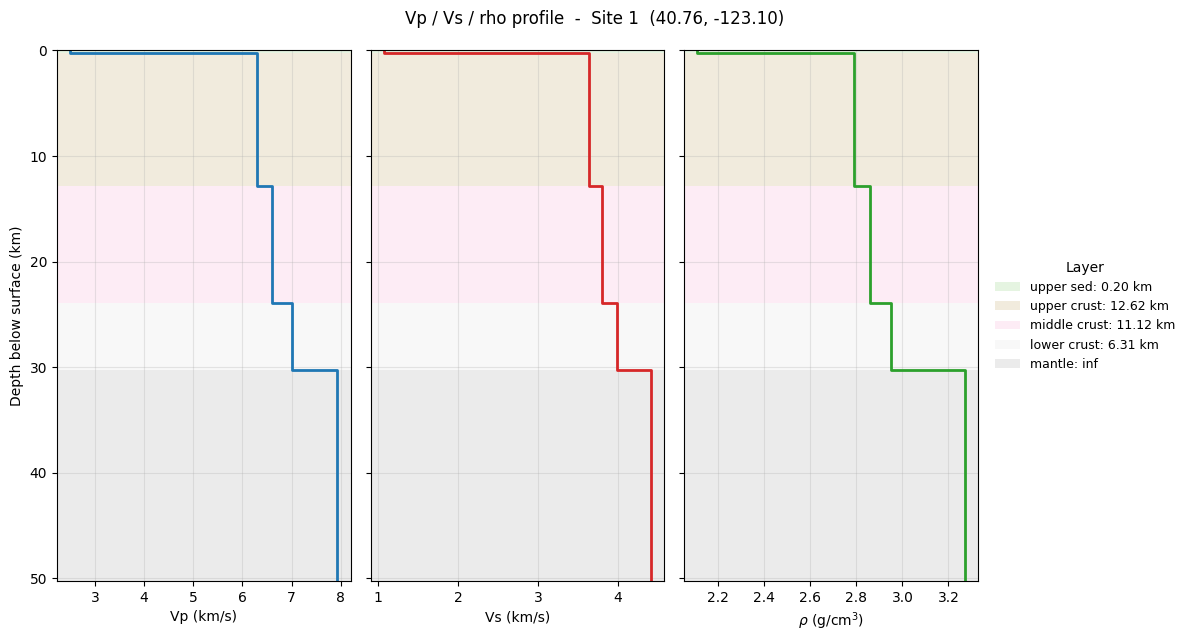

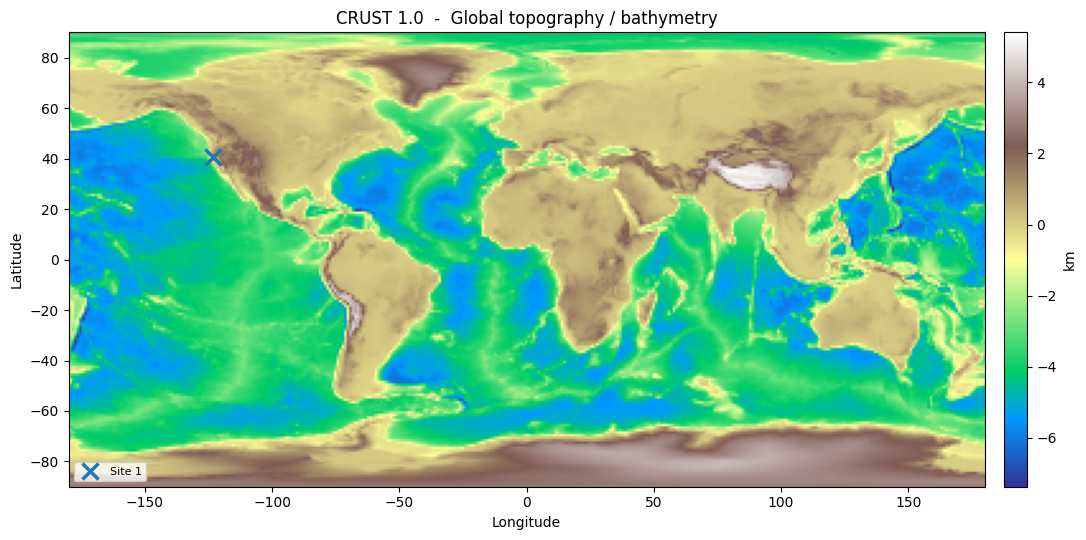

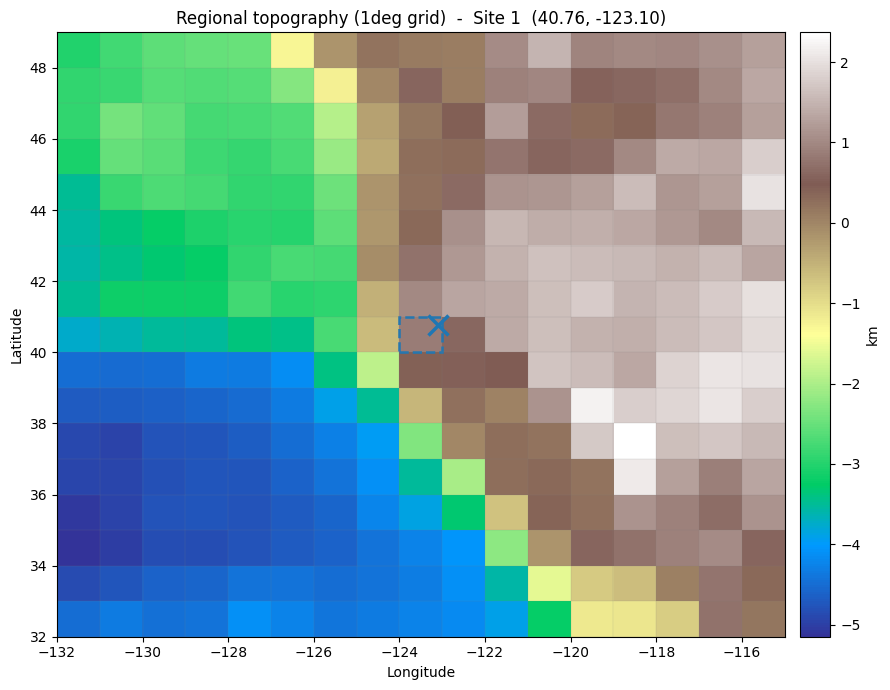

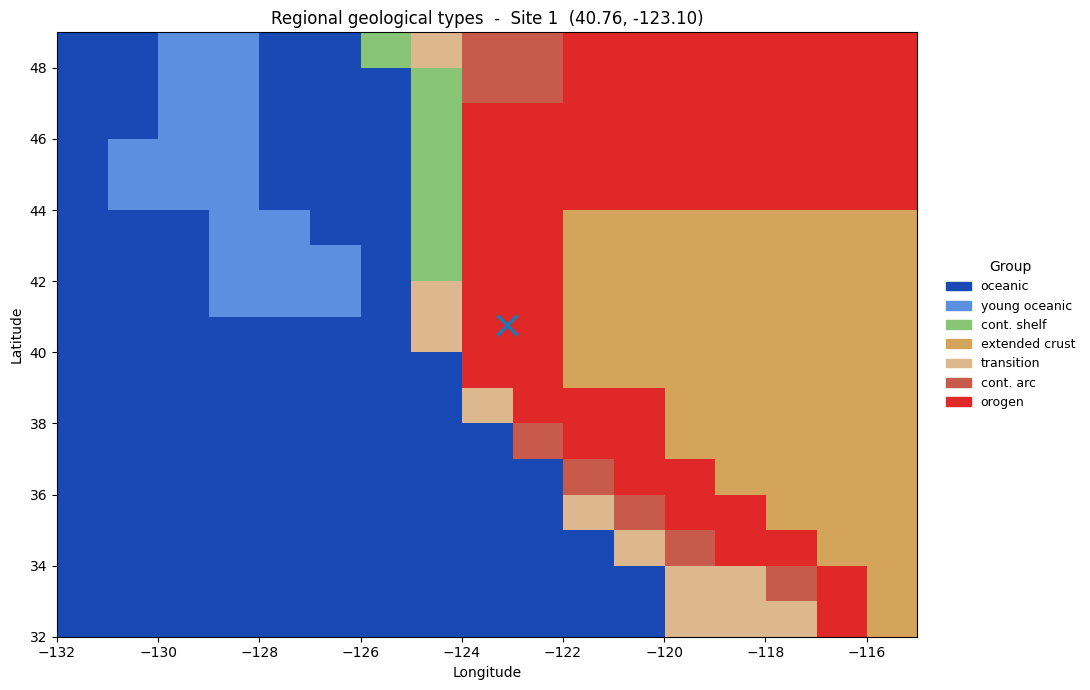

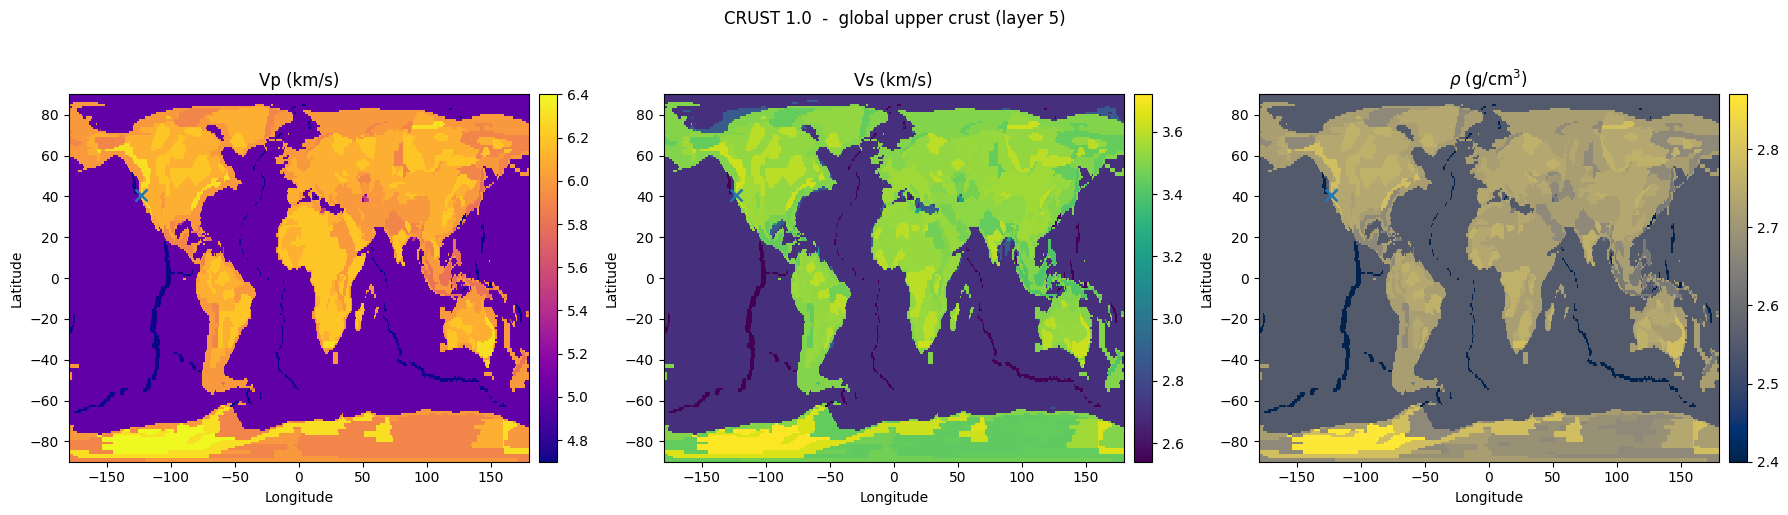

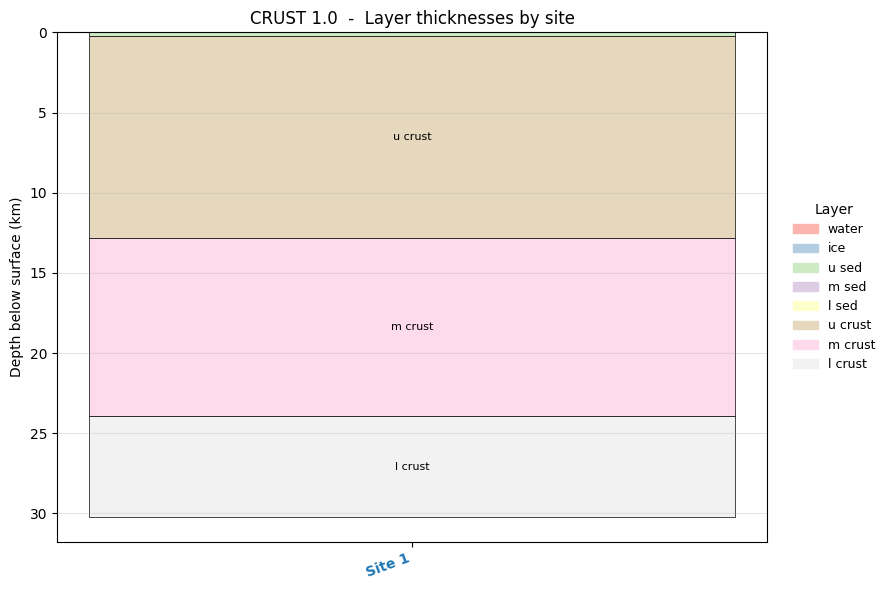

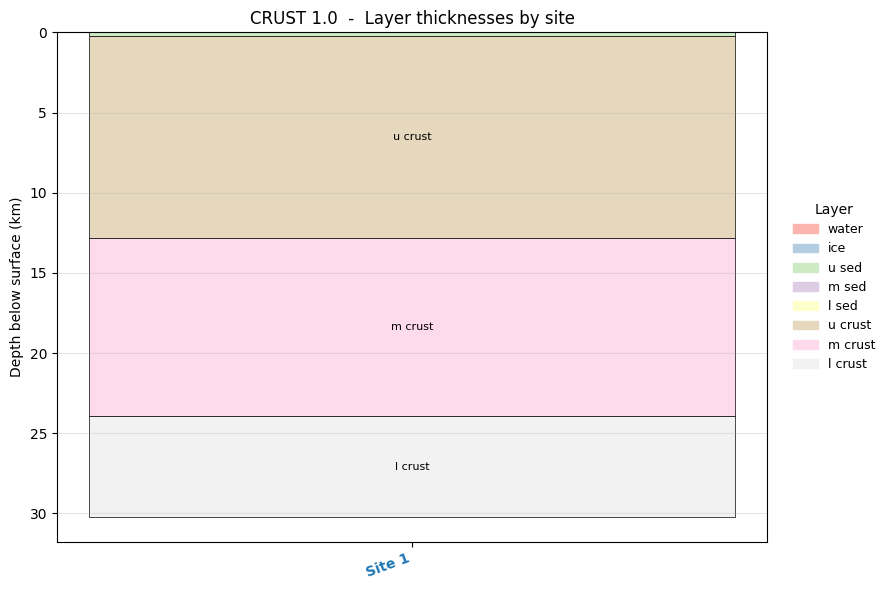

In [1]:
from shakermaker.crust1 import Crust1

# load the global CRUST 1.0 grids (prints the citation on import)
crust1 = Crust1()

lat, lon = 40.764, -123.104

# cell index (row, col) of the 1deg cell containing the point
j, i = crust1.cell_index(lat, lon)

# midpoint (lat, lon) of that cell
mlat, mlon = crust1.cell_midpoint(lat, lon)

# full 9-layer profile at the point (returns a dict)
p = crust1.profile_at(lat, lon)

# geological type code of the cell at the point
t = crust1.type_at(lat, lon)

# print a full layer table for the site
crust1.print_tables((lat, lon))

# print a ready-to-paste ShakerMaker CrustModel snippet
crust1.print_shakermaker((lat, lon))

# Vp, Vs, rho vs depth for the site
crust1.plot_profile((lat, lon))

# global topography with the site marked
crust1.plot_global_topo((lat, lon))

# zoomed topography with 1deg grid and cell outline
crust1.plot_regional_topo((lat, lon))

# regional map of CRUST 1.0 geological type groups
crust1.plot_regional_geological((lat, lon))

# global Vp, Vs, rho maps for one layer (default layer=5)
crust1.plot_global_velocity((lat, lon))

# layer-thickness stratigraphic columns, one per site
crust1.plot_stacked_columns((lat, lon))